<a href="https://colab.research.google.com/github/miftahulhdd/BigData26_B_2411533005_MiftahulHudaAmri/blob/main/praktikum01/BD_B_T01_2411533005_MiftahulHudaAmri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import sys
import time
import psutil
import urllib.request
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from google.colab import drive

In [2]:
drive.mount("/content/drive")
DIR_KERJA = "/content/data"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)

Mounted at /content/drive


In [3]:
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2), "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS delta: {delta:+.1f} MB")
    return hasil

In [4]:
URL_2023_12 = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-12.parquet"
PATH_2023_12 = os.path.join(DIR_KERJA, "yellow_tripdata_2023-12.parquet")

if not os.path.exists(PATH_2023_12):
    ukur("unduh dataset 2036-12", lambda: urllib.request.urlretrieve(URL_2023_12, PATH_2023_12))

meta = pq.ParquetFile(PATH_2023_12).metadata
print("Ukuran file:", round(os.path.getsize(PATH_2023_12) / 1024**2, 1), "MB")
print("Jumlah baris:", f"{meta.num_rows:,}")
print("Jumlah kolom:", meta.num_columns)

[unduh dataset 2036-12] 0.56 s | RSS delta: +0.9 MB
Ukuran file: 54.2 MB
Jumlah baris: 3,376,567
Jumlah kolom: 19


In [5]:
KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH_2023_12))
print("Dimensi:", penuh.shape)
print("Memori:", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH_2023_12, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori:", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

df.head()
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

[baca semua kolom] 1.32 s | RSS delta: +930.9 MB
Dimensi: (3376567, 19)
Memori: 581.6 MB
[baca kolom terpilih] 0.74 s | RSS delta: -19.8 MB
Dimensi: (3376567, 8)
Memori: 206.1 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376567 entries, 0 to 3376566
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 206.1 MB


,0
tpep_pickup_datetime,25.761162
payment_type,25.761162
tpep_dropoff_datetime,25.761162
passenger_count,25.761162
trip_distance,25.761162
tip_amount,25.761162
fare_amount,25.761162
total_amount,25.761162
Index,0.000126


In [6]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"] = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB (hemat {100*(1-sesudah/sebelum):.1f}%)")

df.dtypes

206.1 MB -> 132.0 MB (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


In [7]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"        : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"       : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0" : (df["total_amount"] <= 0).sum(),
}

for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)

bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris (dibuang {len(df)-len(bersih):,})")

       trip_distance  durasi_menit  total_amount
count   3.376567e+06  3.376567e+06  3.376567e+06
mean    3.676258e+00  1.815948e+01  2.854159e+01
std     1.541572e+02  3.878404e+01  2.379225e+01
min     0.000000e+00 -5.995000e+01 -1.094050e+03
25%     1.000000e+00  7.850000e+00  1.596000e+01
50%     1.700000e+00  1.328333e+01  2.140000e+01
75%     3.250000e+00  2.203333e+01  3.156000e+01
max     1.617261e+05  7.188317e+03  4.269160e+03

Nilai kosong per kolom:
 tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          180003
trip_distance                 0
payment_type                  0
fare_amount                   0
tip_amount                    0
total_amount                  0
durasi_menit                  0
dtype: int64
jarak <= 0            : 73,333 baris (2.17%)
durasi <= 0           : 1,075 baris (0.03%)
durasi > 180 menit    : 2,715 baris (0.08%)
total_amount <= 0     : 40,278 baris (1.19%)
3,376,567 baris -> 3,254,176 baris (dibuang 122,391)


In [8]:
CSV_PATH = os.path.join(DIR_KERJA, "trips_2023_12.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV_PATH, index=False))

def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk
    )
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV_PATH))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[tulis CSV] 50.52 s | RSS delta: +5.5 MB
[agregasi chunking] 5.36 s | RSS delta: +16.6 MB
3,254,176 baris | rata-rata total_amount = 29.05


In [9]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-T01")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)
sdf = spark.read.parquet(PATH_2023_12)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

Spark: 4.0.4
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

[spark count] 4.57 s | RSS delta: +0.0 MB
Jumlah baris: 3376567


In [10]:
sdf_bersih = (sdf
    .withColumn("durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+---+------+----------+----------+
|0  |101582|3.57      |28.15     |
|1  |66545 |3.2       |25.59     |
|2  |43032 |3.01      |24.26     |
|3  |28268 |3.5       |26.16     |
|4  |19409 |5.15      |33.52     |
|5  |17076 |6.35      |39.09     |
|6  |38313 |5.18      |32.9      |
|7  |79626 |3.93      |28.78     |
|8  |111091|3.4       |27.43     |
|9  |131236|3.32      |27.61     |
|10 |149194|3.23      |27.72     |
|11 |164063|3.1       |27.65     |
|12 |180650|3.12      |27.86     |
|13 |187169|3.35      |29.03     |
|14 |199442|3.57      |30.48     |
|15 |208424|3.49      |30.31     |
|16 |203533|3.49      |32.17     |
|17 |217266|3.16      |30.63     |
|18 |225065|2.96      |29.02     |
|19 |203559|3.16      |29.2      |
|20 |183429|3.26      |28.37     |
|21 |183569|3.28      |28.04     |
|22 |172189|3.48      |28.77     |
|23 |140446|3.68      |29.33     |
+---+------+----------+----------+

[spark agregasi] 6.

In [11]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
SELECT payment_type,
       COUNT(*) AS jumlah,
       ROUND(AVG(total_amount), 2) AS rata_tarif,
       ROUND(AVG(tip_amount), 2) AS rata_tip
FROM trips
GROUP BY payment_type
ORDER BY jumlah DESC
""").show()

hasil_spark.explain()
spark.stop()

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2545742|     29.86|    4.46|
|           2| 523038|     25.38|     0.0|
|           0| 148847|     29.01|    2.05|
|           4|  24840|     25.78|    0.02|
|           3|  11709|     23.83|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#44 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#44 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=202]
      +- HashAggregate(keys=[jam#44], functions=[count(1), avg(trip_distance#4), avg(total_amount#16)])
         +- Exchange hashpartitioning(jam#44, 8), ENSURE_REQUIREMENTS, [plan_id=199]
            +- HashAggregate(keys=[jam#44], functions=[partial_count(1), partial_avg(trip_distance#4), partial_avg(total_amount#16)])
               +- Project [trip_distance#4, total_amount#16, hour(tpep_pickup_datetime#1, Some(

In [12]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,101582,3.57,14.55,28.150000,21.969999
1,1,66545,3.20,12.78,25.590000,20.520000
2,2,43032,3.01,11.89,24.260000,19.799999
3,3,28268,3.50,12.13,26.160000,20.410000
4,4,19409,5.15,14.46,33.520000,22.980000
5,5,17076,6.35,16.27,39.090000,23.280001
6,6,38313,5.18,16.13,32.900002,19.600000
7,7,79626,3.93,15.86,28.780001,19.299999
8,8,111091,3.40,15.83,27.430000,19.400000
9,9,131236,3.32,16.20,27.610001,20.000000


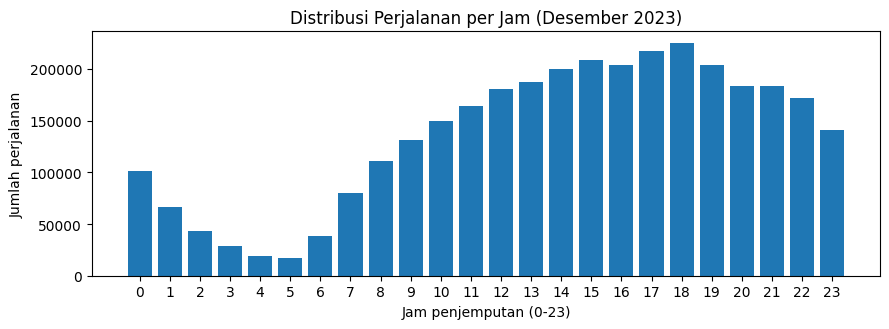

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi Perjalanan per Jam (Desember 2023)")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam_2023_12.png", dpi=150)
plt.show()

Tabel Perbandingan Pola Per Jam
 jam  Desember_2023  Januari_2023
   0         101582         82289
   1          66545         57766
   2          43032         40445
   3          28268         26146
   4          19409         16618
   5          17076         16940
   6          38313         42300
   7          79626         84569
   8         111091        114064
   9         131236        127988
  10         149194        140230
  11         164063        150539
  12         180650        165714
  13         187169        174183
  14         199442        186741
  15         208424        191392
  16         203533        190689
  17         217266        204399
  18         225065        210858
  19         203559        188347
  20         183429        161789
  21         183569        157770
  22         172189        143800
  23         140446        111335


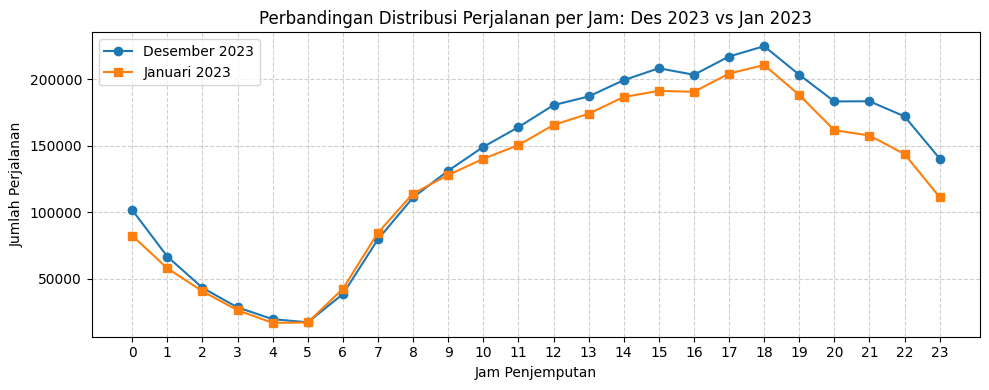

In [14]:
URL_2023_01 = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
PATH_2023_01 = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH_2023_01):
    urllib.request.urlretrieve(URL_2023_01, PATH_2023_01)

df2 = pd.read_parquet(PATH_2023_01, columns=KOLOM)
df2["durasi_menit"] = (df2["tpep_dropoff_datetime"] - df2["tpep_pickup_datetime"]).dt.total_seconds() / 60
layak2 = (
    (df2["trip_distance"] > 0) & (df2["trip_distance"] < 100) &
    df2["durasi_menit"].between(1, 180) & (df2["total_amount"] > 0)
)
bersih2 = df2.loc[layak2].copy()
bersih2["jam"] = bersih2["tpep_pickup_datetime"].dt.hour

agregasi2 = (
    bersih2.groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"))
    .reset_index()
)

# Tabel Perbandingan
tabel_komparasi = pd.merge(
    agregasi[["jam", "jumlah_perjalanan"]].rename(columns={"jumlah_perjalanan": "Desember_2023"}),
    agregasi2[["jam", "jumlah_perjalanan"]].rename(columns={"jumlah_perjalanan": "Januari_2023"}),
    on="jam"
)
print("Tabel Perbandingan Pola Per Jam")
print(tabel_komparasi.to_string(index=False))

# Grafik Perbandingan
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tabel_komparasi["jam"], tabel_komparasi["Desember_2023"], marker='o', label='Desember 2023')
ax.plot(tabel_komparasi["jam"], tabel_komparasi["Januari_2023"], marker='s', label='Januari 2023')
ax.set_xlabel("Jam Penjemputan")
ax.set_ylabel("Jumlah Perjalanan")
ax.set_title("Perbandingan Distribusi Perjalanan per Jam: Des 2023 vs Jan 2023")
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/komparasi_des_jan_2023.png", dpi=150)
plt.show()

In [15]:
pd.DataFrame(catatan)

,langkah,detik,delta_rss_mb
0,unduh dataset 2036-12,0.56,0.9
1,baca semua kolom,1.32,930.9
2,baca kolom terpilih,0.74,-19.8
3,tulis CSV,50.52,5.5
4,agregasi chunking,5.36,16.6
5,spark count,4.57,0.0
6,spark agregasi,6.24,0.0
